<a href="https://colab.research.google.com/github/EmilyHong77/degentrificAItion/blob/main/model_training_Emilie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Replace 'your_dataset.csv' with your actual dataset file path
data = pd.read_csv('/content/drive/MyDrive/GentrificAItion/Montreal_data_from_census/Standardized_Census_Data/important_features.csv')

# Display the first few rows of the dataset
print(data.head())
column_name = "Population percentage change, 2001-2006 2006"

# Calculate the average of non-inf values
average_without_inf = data.loc[~data[column_name].isin([np.inf, -np.inf]), column_name].mean()

# Replace inf values with the calculated average
data['Population percentage change, 2001-2006 2006'].replace([np.inf, -np.inf], average_without_inf, inplace=True)

       ctuid  All others 2001  \
0       -1.0              0.0   
1  4620001.0           2395.0   
2  4620002.0           2595.0   
3  4620002.0           2595.0   
4  4620003.0           6065.0   

   Apartment, building that has fewer than five storeys 2001  \
0                                                0.0           
1                                             1025.0           
2                                              690.0           
3                                              690.0           
4                                             2250.0           

   Average gross rent $ 2001  Average value of dwelling $ 2001  Bicycle 2001  \
0                        0.0                               0.0           0.0   
1                      554.0                          107148.0        3010.0   
2                      528.0                          107098.0         150.0   
3                      528.0                          107098.0         150.0   
4               

In [3]:
# Convert non-numeric values to NaN in each column
columns_to_convert = data.keys()
for col in columns_to_convert:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Fill missing values with the average
for col in columns_to_convert:
    average_value = data[col].mean()
    data[col].fillna(average_value, inplace=True)

# Convert specific columns to float
data[columns_to_convert] = data[columns_to_convert].astype(float)

# Display the updated dataset
print(data.head())

       ctuid  All others 2001  \
0       -1.0              0.0   
1  4620001.0           2395.0   
2  4620002.0           2595.0   
3  4620002.0           2595.0   
4  4620003.0           6065.0   

   Apartment, building that has fewer than five storeys 2001  \
0                                                0.0           
1                                             1025.0           
2                                              690.0           
3                                              690.0           
4                                             2250.0           

   Average gross rent $ 2001  Average value of dwelling $ 2001  Bicycle 2001  \
0                        0.0                               0.0           0.0   
1                      554.0                          107148.0        3010.0   
2                      528.0                          107098.0         150.0   
3                      528.0                          107098.0         150.0   
4               

In [ ]:
'''
# Check for inf values in the entire DataFrame
inf_values = data.isin([float('inf'), float('-inf')])

# Check if any column contains inf values
inf_in_columns = inf_values.any()

# Check if any row contains inf values
inf_in_rows = inf_values.any(axis=1)

# Print columns containing inf values
print("Columns containing inf values:")
print(inf_in_columns[inf_in_columns])

# Print rows containing inf values
print("\nRows containing inf values:")
print(data[inf_in_rows])
'''

Columns containing inf values:
Population percentage change, 2001-2006 2006    True
dtype: bool

Rows containing inf values:
      Unnamed: 0.1       ctuid  All others 2001  \
0              0.0       -1.00         0.000000   
17            17.0  4620014.02         0.000000   
44            44.0  4620040.00         0.000000   
47            47.0  4620043.00       845.000000   
58            58.0  4620054.00         0.000000   
...            ...         ...              ...   
1003        1003.0  4622304.00      3022.377066   
1004        1004.0  4622400.00      3022.377066   
1005        1005.0  4622401.00      3022.377066   
1006        1006.0  4622402.00      3022.377066   
1007        1007.0      462.00      3022.377066   

      Apartment, building that has fewer than five storeys 2001  \
0                                              0.000000           
17                                             0.000000           
44                                             0.000000      

# 1 Find Important Predictors of Gentrification

In [6]:
# specificy which columns to drop depending on what target is

# predict Gentrifiable
Gentrifiable_2021 = ["ctuid",
                     "Median total income of household in 2020 ($) 2021",
                     "Gentrified Ding 2021",
                     "Gentrified Ding 2021"]

# predict Gentrified
Gentrified_2021 = ["ctuid",
                   "Average value of dwellings ($) 2021",
                   "Median monthly shelter costs for rented dwellings ($) 2021",
                   "Bachelor's degree or higher 2021",
                   "Gentrification Level Ding 2021"
                   ]

# predict Gentrification Level
Gen_Levels_2021 = ["ctuid",
                   "Average value of dwellings ($) 2021",
                   "Median monthly shelter costs for rented dwellings ($) 2021",
                   "Bachelor's degree or higher 2021",
                   "Gentrified Ding 2021"
                   ]


In [7]:
# drop the column that is your target
data = data.drop(Gentrifiable_2021, axis=1)
# data = data.drop(Gentrified_2021, axis=1)
# data = data.drop(Gen_Levels_2021, axis=1)

In [8]:
# Specify which column we wish the model to predict
target_column_gentrifiable_2021 = "Gentrifiable Ding 2021"
target_column_gentrified_2021 = "Gentrified Ding 2021"
target_column_gen_levels_2021 = "Gentrification Level Ding 2021"

0       0.0
1       1.0
2       1.0
3       0.0
4       1.0
       ... 
1003    0.0
1004    0.0
1005    0.0
1006    0.0
1007    0.0
Name: Gentrifiable Ding 2021, Length: 1008, dtype: float64


In [9]:
# Specify which column we wish the model to predict
target_column = target_column_gentrifiable_2021

'''
# Calculate the median of target column --> not necessary for Gentrified Measure
# median_target = data[target_column].median()

# Create a new binary label column --> not necessary for Gentrified Measure
# data[target_column] = (data[target_column] > median_target).astype(int)
'''

# Define features and target
X = data.drop(target_column, axis=1)
y = data[target_column]
print(y)

0       0.0
1       1.0
2       1.0
3       0.0
4       1.0
       ... 
1003    0.0
1004    0.0
1005    0.0
1006    0.0
1007    0.0
Name: Gentrifiable Ding 2021, Length: 1008, dtype: float64


In [10]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to DMatrix (XGBoost's internal data structure)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Define parameters
params = {
    'objective': 'multi:softprob',  # Specify multiclass classification
    'num_class': 2,  # NUMBER OF CLASSES 4 for Level of gentrification
    'eval_metric': 'mlogloss',  # Evaluation metric
    'max_depth': 4,  # Maximum depth of a tree
    'eta': 0.3,  # Learning rate
    'seed': 42  # Random seed for reproducibility
}

# Train the model
bst = xgb.train(params, dtrain, num_boost_round=100)

# Make predictions
y_pred_prob = bst.predict(dtest)
y_pred = y_pred_prob.argmax(axis=1)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.99


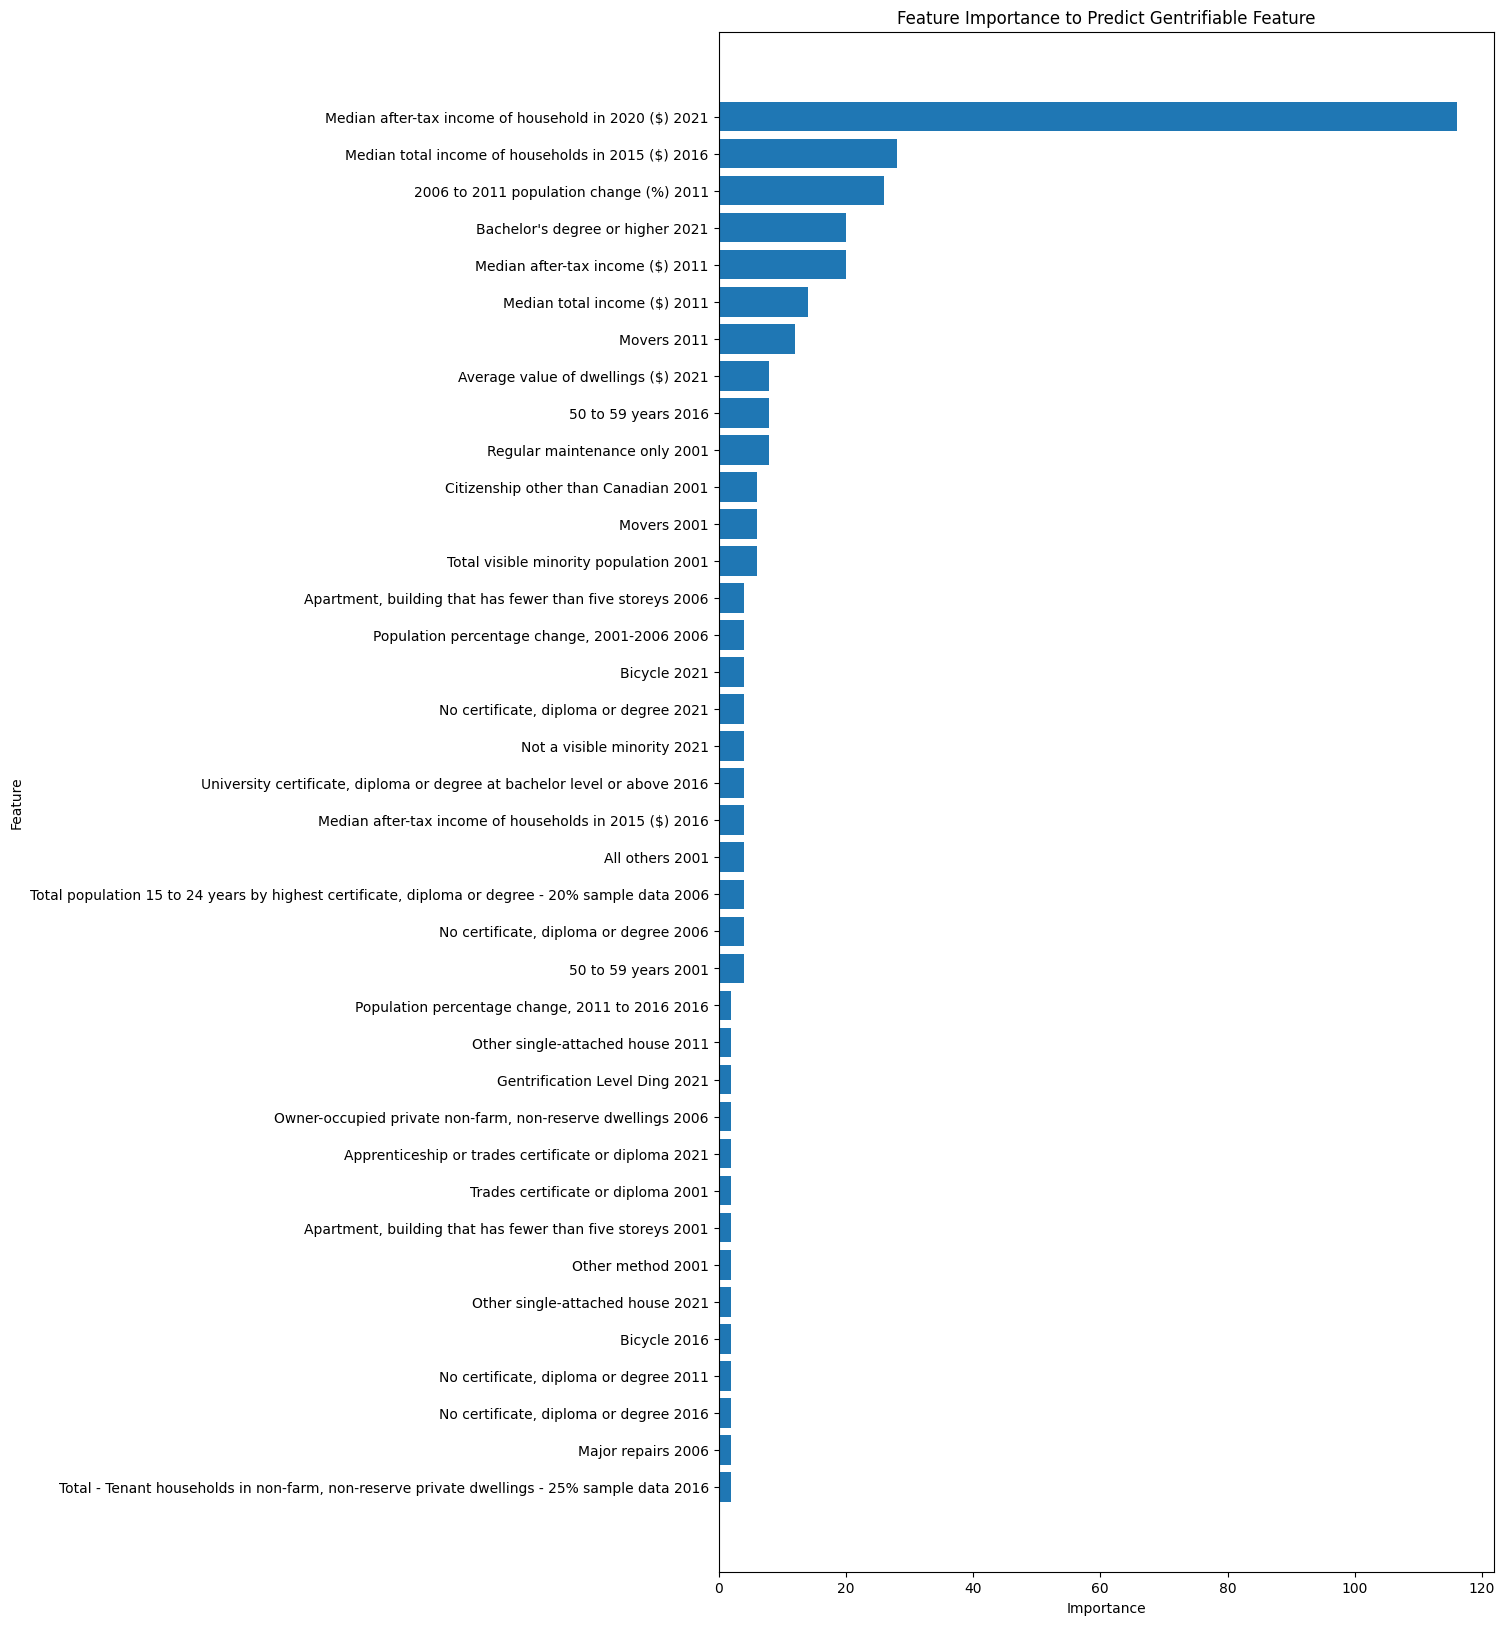

In [18]:
# Extract and plot feature importance
importance = bst.get_score(importance_type='weight')
importance_df = pd.DataFrame(importance.items(), columns=['Feature', 'Importance']).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 20))
plt.barh(importance_df['Feature'].iloc[:50], importance_df['Importance'].iloc[:50])
plt.xlabel('Importance')
plt.ylabel('Feature')

# change title for each target
plt.title('Feature Importance to Predict Gentrifiable Feature')
plt.gca().invert_yaxis()
plt.show()

In [17]:
# Save the plot as an image file to Google Drive
plt.savefig('/content/drive/My Drive/GentrificAItion/ModelOutputs/feat_imp_2021_gentrifiable.png', bbox_inches='tight')
plt.close('all')

# 2 Predict Gentrification for 2021

# 3 Predict Gentrification for 2026